In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
%cd drive/MyDrive/Colab Notebooks/CPSC322/Final Project Classifiers
%ls

[Errno 2] No such file or directory: 'drive/MyDrive/Colab Notebooks/CPSC322/Final Project Classifiers'
/content/drive/MyDrive/Colab Notebooks/CPSC322/Final Project Classifiers
EDA.ipynb  KNN.ipynb  Naive_Bayes.ipynb  Report.ipynb  tmdb_clean_step1.csv


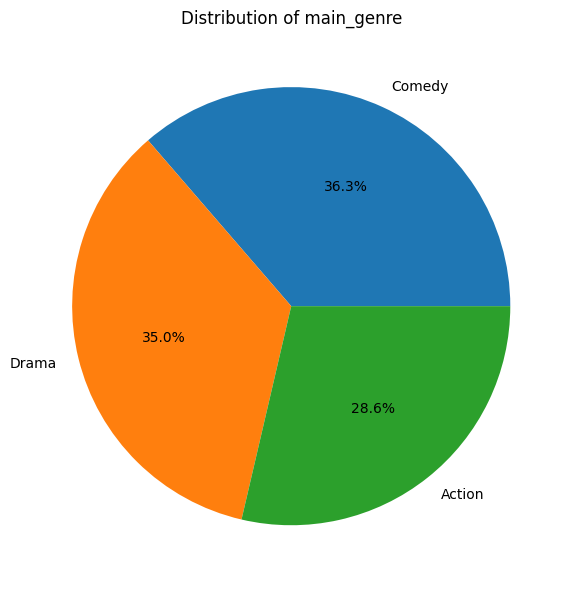

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load CSV file ---
df = pd.read_csv('tmdb_clean_step1.csv')

# --- Choose the attribute/column to visualize ---
attribute = "main_genre"

# --- Count occurrences of each unique value ---
counts = df[attribute].value_counts()

# --- Plot pie chart ---
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title(f"Distribution of {attribute}")
plt.tight_layout()
plt.show()

In [19]:
def scatter_class(df, x_attr, y_attr, label_col, x_lim=[]):
  # --- Create scatter plot ---
  plt.figure(figsize=(8, 6))

  # Loop through each class and plot separately
  for label in df[label_col].unique():
      subset = df[df[label_col] == label]
      plt.scatter(
          subset[x_attr],
          subset[y_attr],
          label=str(label),
          alpha=0.7
      )

  plt.xlabel(x_attr, fontsize=12)
  plt.ylabel(y_attr, fontsize=12)
  plt.title(f"Scatter Plot of {x_attr} vs {y_attr}", fontsize=14)
  if len(x_lim) != 0:
    plt.xlim(x_lim[0], x_lim[1])
  plt.legend(title=label_col)
  plt.tight_layout()
  plt.show()

In [20]:
def box_plot_class(df, numeric_feature, label_col, ylim=None):
  # --- Prepare data for boxplot ---
  # Create a list of series, one for each class
  data_per_class = [df[df[label_col] == cls][numeric_feature] for cls in df[label_col].unique()]
  class_labels = df[label_col].unique()

  # --- Plot ---
  plt.figure(figsize=(8, 6))
  plt.boxplot(data_per_class, labels=class_labels, patch_artist=True)
  if ylim is not None:
    plt.ylim(0, ylim)
  plt.xlabel(label_col, fontsize=12)
  plt.ylabel(numeric_feature, fontsize=12)
  plt.title(f"Boxplot of {numeric_feature} by {label_col}", fontsize=14)
  plt.tight_layout()
  plt.show()

/tmp/ipython-input-3283231667.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_per_class, labels=class_labels, patch_artist=True)


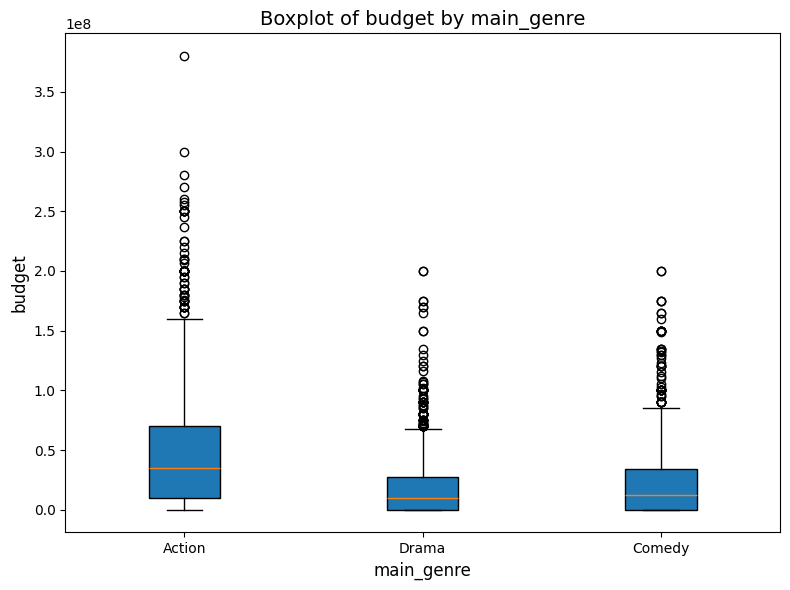

In [21]:
label_col = "main_genre"
numeric_feature = "budget"
box_plot_class(df, numeric_feature, label_col)

/tmp/ipython-input-3283231667.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_per_class, labels=class_labels, patch_artist=True)


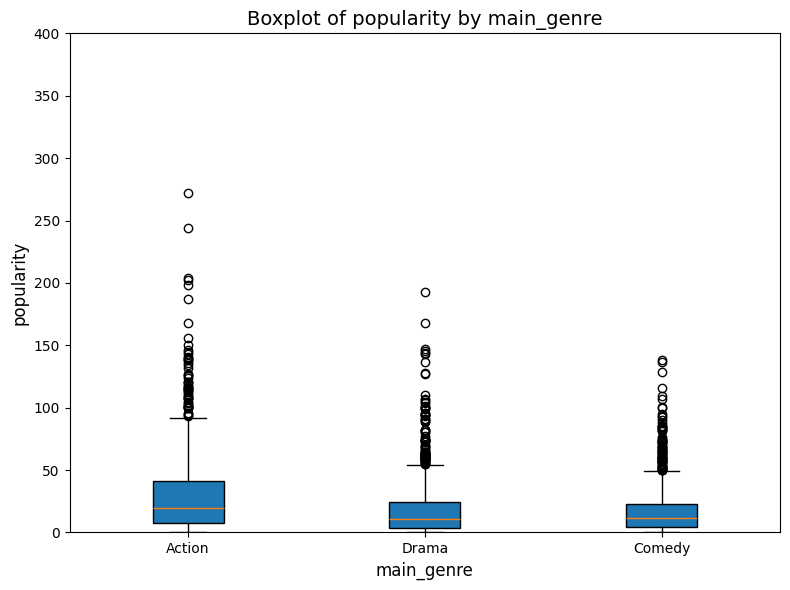

In [22]:
label_col = "main_genre"
numeric_feature = "popularity"
box_plot_class(df, numeric_feature, label_col, ylim=400)

/tmp/ipython-input-3283231667.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_per_class, labels=class_labels, patch_artist=True)


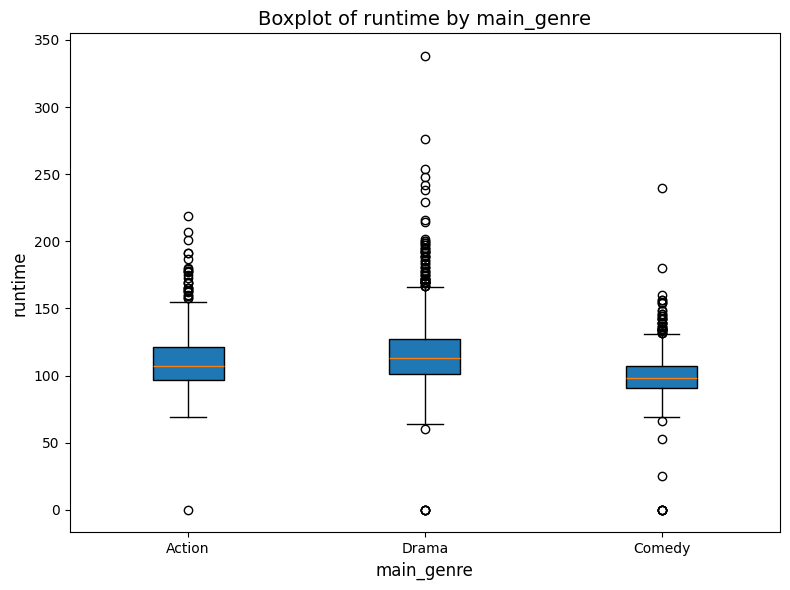

In [23]:
label_col = "main_genre"
numeric_feature = "runtime"
box_plot_class(df, numeric_feature, label_col)

/tmp/ipython-input-3283231667.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_per_class, labels=class_labels, patch_artist=True)


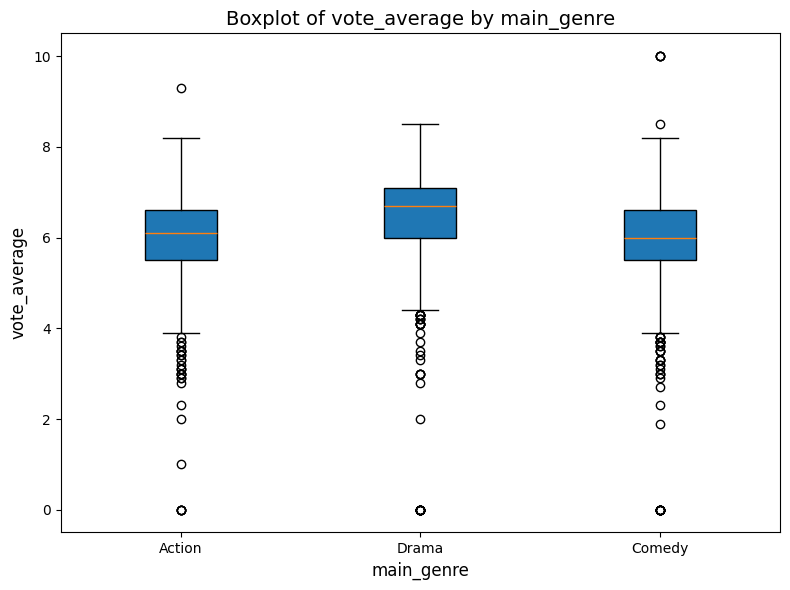

In [24]:
label_col = "main_genre"
numeric_feature = "vote_average"
box_plot_class(df, numeric_feature, label_col)

/tmp/ipython-input-3283231667.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_per_class, labels=class_labels, patch_artist=True)


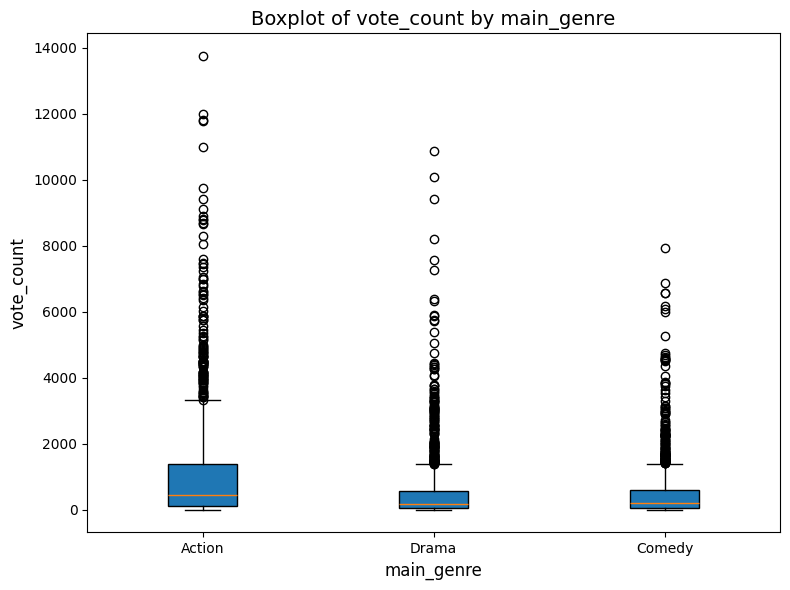

In [25]:
label_col = "main_genre"
numeric_feature = "vote_count"
box_plot_class(df, numeric_feature, label_col)

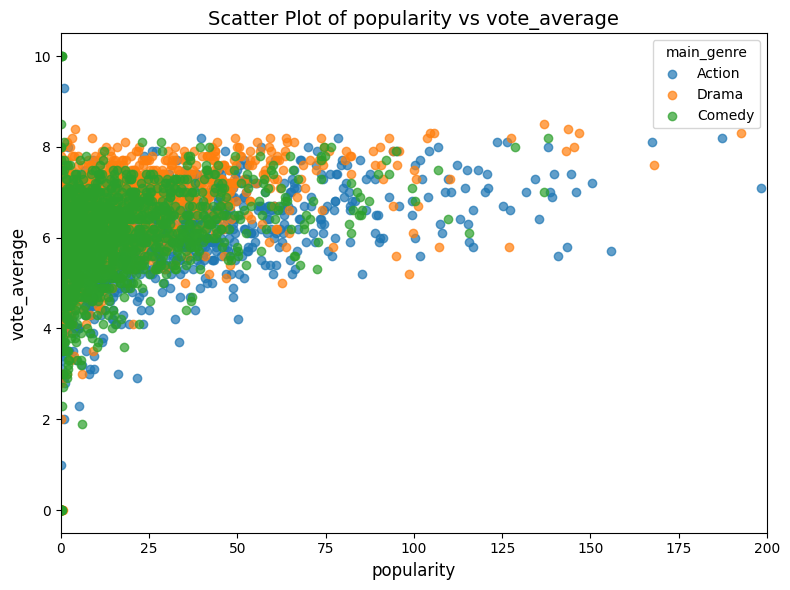

In [26]:
# --- Choose your two attributes ---
x_attr = "popularity"
y_attr = "vote_average"

# --- Class label column ---
label_col = "main_genre"

scatter_class(df, x_attr, y_attr, label_col, (0, 200))

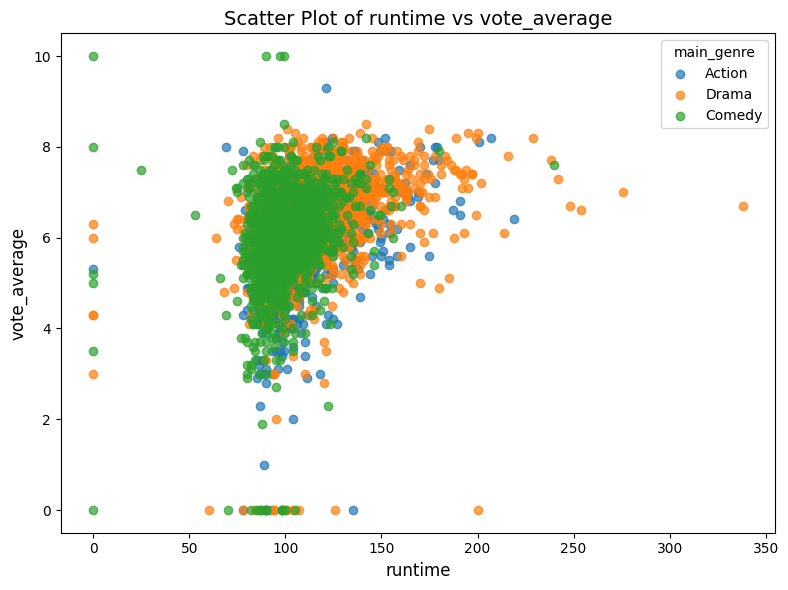

In [27]:
# --- Choose your two attributes ---
x_attr = "runtime"
y_attr = "vote_average"

# --- Class label column ---
label_col = "main_genre"

scatter_class(df, x_attr, y_attr, label_col)

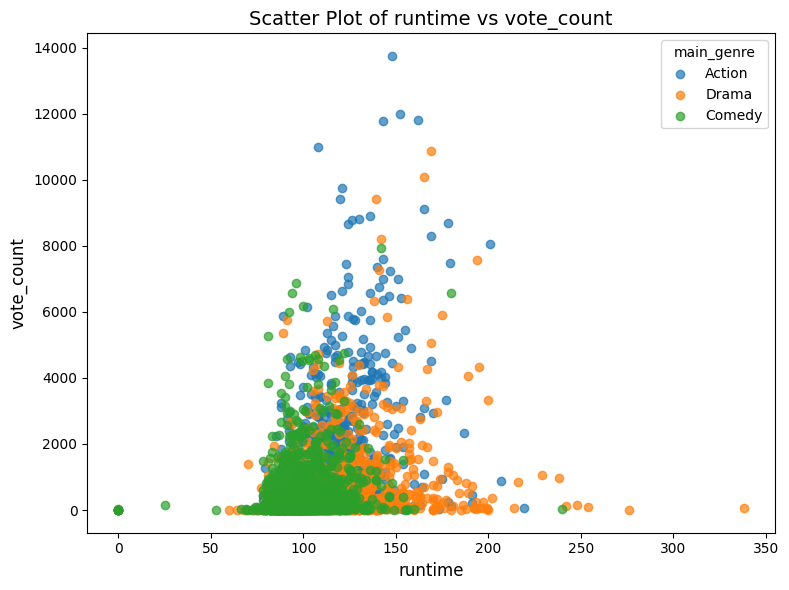

In [28]:
# --- Choose your two attributes ---
x_attr = "runtime"
y_attr = "vote_count"

# --- Class label column ---
label_col = "main_genre"

scatter_class(df, x_attr, y_attr, label_col)

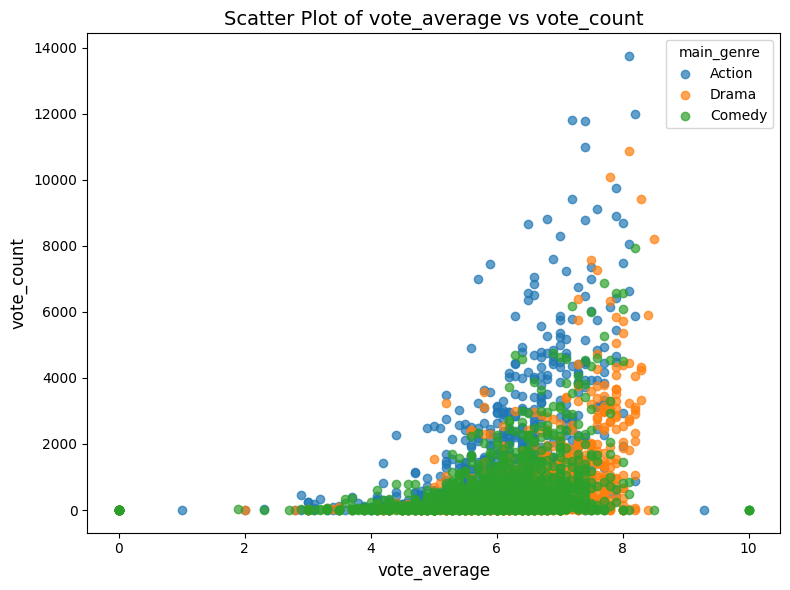

In [29]:
# --- Choose your two attributes ---
x_attr = "vote_average"
y_attr = "vote_count"

# --- Class label column ---
label_col = "main_genre"

scatter_class(df, x_attr, y_attr, label_col)

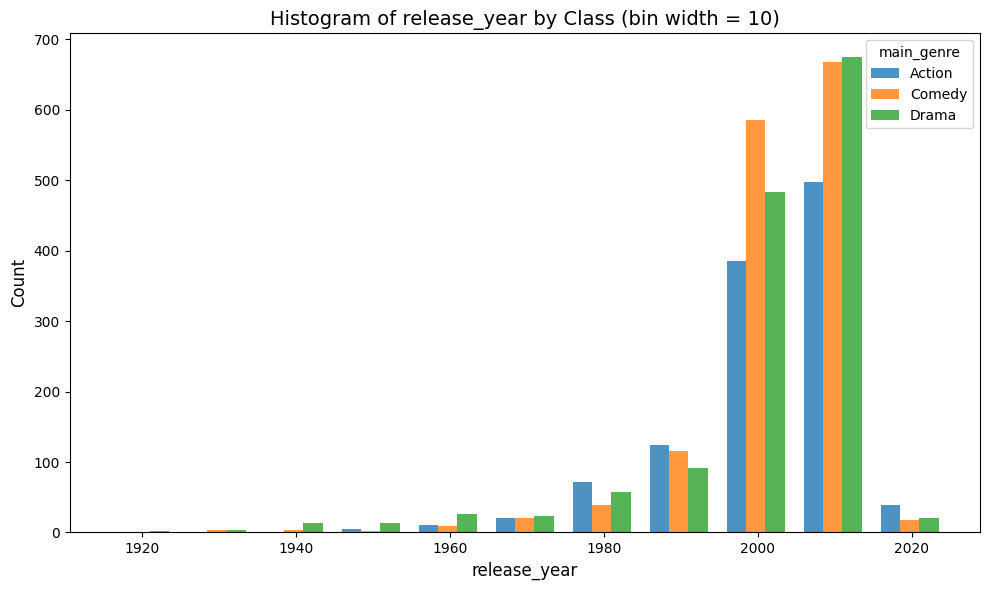

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Choose numeric attribute and class label ---
numeric_attr = "release_year"
label_col = "main_genre"

# --- Pre-defined bin width ---
bin_width = 10   # <-- Set this to what you want

# --- Compute bin edges automatically ---
values = df[numeric_attr]
min_val = values.min()
max_val = values.max()

# Ensure full coverage of the data range
bin_edges = np.arange(min_val, max_val + bin_width, bin_width)

# --- Class labels ---
classes = df[label_col].unique()
classes.sort()

# --- Count instances per class per bin ---
counts = {
    cls: np.histogram(df[df[label_col] == cls][numeric_attr], bins=bin_edges)[0]
    for cls in classes
}

# --- Prepare for plotting ---
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
width = (bin_edges[1] - bin_edges[0]) / (len(classes) + 1)

plt.figure(figsize=(10, 6))

# --- Plot bars for each class ---
for i, cls in enumerate(classes):
    plt.bar(
        bin_centers + i * width - (len(classes) * width) / 2,
        counts[cls],
        width=width,
        alpha=0.8,
        label=str(cls)
    )

plt.xlabel(numeric_attr, fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title(f"Histogram of {numeric_attr} by Class (bin width = {bin_width})", fontsize=14)
plt.legend(title=label_col)
plt.tight_layout()
plt.show()